# House Prices — improved simple polynomial regression
This notebook uses richer numeric and domain features, a log-transformed target, documented outlier handling, degree comparison, and residual analysis. The estimator remains `LinearRegression` on polynomial features.

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))
from src.modeling import (
    MODEL_FEATURES, TARGET, cross_validate_degrees, fit_model,
    outlier_mask, predict_prices, prepare_features, regression_metrics,
    select_best_degree,
)

## Load and inspect the data

In [2]:
train = pd.read_csv(ROOT / 'data' / 'train.csv')
test = pd.read_csv(ROOT / 'data' / 'test.csv')
print('Train:', train.shape, 'Test:', test.shape)
train['SalePrice'].describe()

Train: (1460, 81) Test: (1459, 80)


count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

## Documented outlier handling and feature engineering
The rule flags houses above 4,000 sq ft that sold below $300,000. We report and remove these unusual training observations rather than hiding the decision.

In [3]:
flagged = outlier_mask(train)
display(train.loc[flagged, ['Id', 'GrLivArea', 'SalePrice']])
modeling_train = train.loc[~flagged].reset_index(drop=True)
X = prepare_features(modeling_train)
y = modeling_train[TARGET]
print('Rows retained:', len(modeling_train))
print('Model features:', MODEL_FEATURES)
X.head()

,Id,GrLivArea,SalePrice
523,524,4676,184750
1298,1299,5642,160000


Rows retained: 1458
Model features: ['OverallQual', 'OverallCond', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotRmsAbvGrd', 'Fireplaces', 'BedroomAbvGr', 'TotalSF', 'HouseAge', 'RemodelAge', 'TotalBathrooms', 'TotalPorchSF', 'HasGarage', 'HasBasement', 'HasFireplace']


,OverallQual,OverallCond,GrLivArea,GarageCars,GarageArea,TotRmsAbvGrd,Fireplaces,BedroomAbvGr,TotalSF,HouseAge,RemodelAge,TotalBathrooms,TotalPorchSF,HasGarage,HasBasement,HasFireplace
0,7,5,1710,2,548,8,0,3,2566,5,5,2.5,61,1,1,0
1,6,8,1262,2,460,6,1,3,2524,31,31,2.0,0,1,1,1
2,7,5,1786,2,608,6,1,3,2706,7,6,2.5,42,1,1,1
3,7,5,1717,3,642,7,1,3,2473,91,36,1.0,307,1,1,1
4,8,5,2198,3,836,9,1,4,3343,8,8,2.5,84,1,1,1


## Repeated cross-validation: degree 1 versus degree 2
This uses five repeats of five-fold CV (25 matched splits). The degree with the lowest repeated-CV RMSE is selected as the final model.

In [4]:
degree_results = pd.DataFrame(cross_validate_degrees(X, y, degrees=(1, 2), n_splits=5, n_repeats=5))
best_degree = select_best_degree(degree_results.to_dict('records'), metric='CV_RMSE')
print('Selected degree:', best_degree)
degree_results

Selected degree: 1


,degree,CV_MAE,CV_RMSE,CV_RMSE_std,CV_RMSE_95CI_low,CV_RMSE_95CI_high,CV_R2,folds,repeats,evaluations
0,1,17685.81,25773.41,2084.93,24956.12,26590.71,0.8930,5,5,25
1,2,18238.90,27335.27,2236.92,26458.40,28212.14,0.8795,5,5,25


## Train and compare both degrees on the holdout
Preprocessing is learned from the training split only. The target uses `log1p`, and predictions are returned to dollars with `expm1`.

In [5]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.20, random_state=42
)
holdout_results = []
holdout_predictions = {}
for degree in (1, 2):
    fitted = fit_model(X_train, y_train, degree=degree)
    holdout_predictions[degree] = predict_prices(fitted, X_valid)
    holdout_results.append({'degree': degree, **regression_metrics(y_valid, holdout_predictions[degree])})
valid_pred = holdout_predictions[best_degree]
pd.DataFrame(holdout_results)

,degree,MAE,RMSE,R2
0,1,17957.65,24450.04,0.8918
1,2,17464.30,24112.02,0.8947


## Residual diagnostics

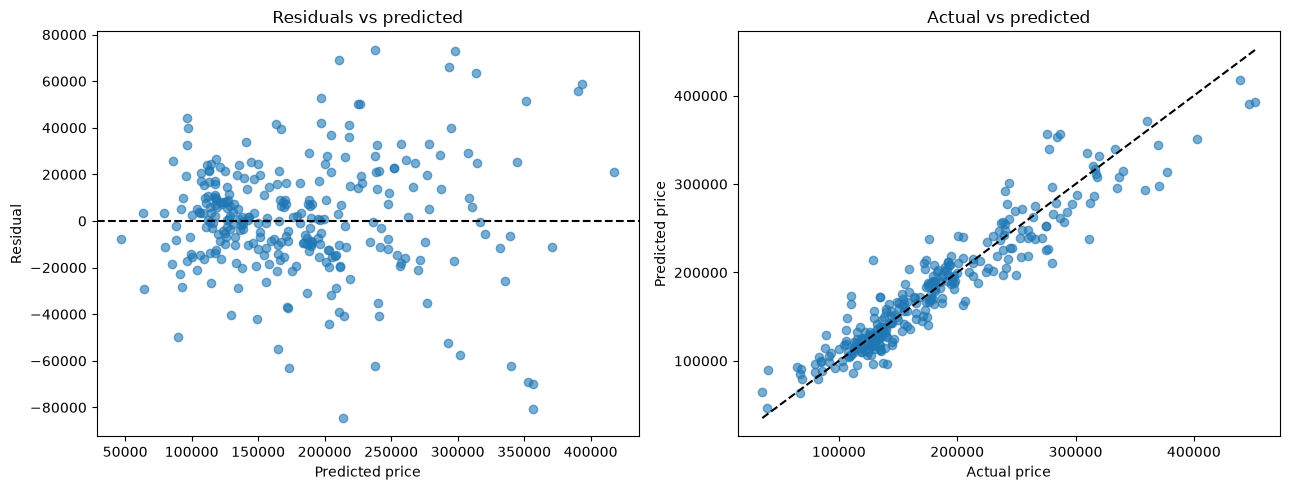

,Actual,Predicted,Residual,AbsoluteError
665,129000,213580.021232,-84580.021232,84580.021232
261,276000,356492.553348,-80492.553348,80492.553348
218,311500,237995.470775,73504.529225,73504.529225
643,370878,298116.203492,72761.796508,72761.796508
1023,287000,357009.421650,-70009.421650,70009.421650
332,284000,353011.270369,-69011.270369,69011.270369
451,280000,211061.110498,68938.889502,68938.889502
607,359100,293178.306562,65921.693438,65921.693438
1386,377500,313884.569671,63615.430329,63615.430329
727,110000,173213.563756,-63213.563756,63213.563756


In [6]:
diagnostics = pd.DataFrame({'Actual': y_valid, 'Predicted': valid_pred})
diagnostics['Residual'] = diagnostics['Actual'] - diagnostics['Predicted']
diagnostics['AbsoluteError'] = diagnostics['Residual'].abs()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(diagnostics['Predicted'], diagnostics['Residual'], alpha=0.6)
axes[0].axhline(0, color='black', linestyle='--')
axes[0].set(xlabel='Predicted price', ylabel='Residual', title='Residuals vs predicted')
axes[1].scatter(diagnostics['Actual'], diagnostics['Predicted'], alpha=0.6)
low = min(diagnostics['Actual'].min(), diagnostics['Predicted'].min())
high = max(diagnostics['Actual'].max(), diagnostics['Predicted'].max())
axes[1].plot([low, high], [low, high], '--', color='black')
axes[1].set(xlabel='Actual price', ylabel='Predicted price', title='Actual vs predicted')
plt.tight_layout()
plt.show()
diagnostics.nlargest(10, 'AbsoluteError')

## Refit both degrees and save the selected submission

In [7]:
OUTPUTS = ROOT / 'outputs'
OUTPUTS.mkdir(exist_ok=True)
submissions = {}
for degree in (1, 2):
    final_fitted = fit_model(X, y, degree=degree)
    test_pred = predict_prices(final_fitted, prepare_features(test))
    submissions[degree] = pd.DataFrame({'Id': test['Id'], TARGET: test_pred})
    submissions[degree].to_csv(OUTPUTS / 'submissions' / f'degree_{degree}_submission.csv', index=False)
submission = submissions[best_degree]
submission.to_csv(OUTPUTS / 'submissions' / 'polynomial_submission.csv', index=False)
submission.head()

,Id,SalePrice
0,1461,120366.797261
1,1462,144110.495063
2,1463,168610.633285
3,1464,190542.470983
4,1465,191902.924785


## Conclusion
The project still uses only polynomial regression. Degree 1 is selected because it has the lower RMSE across 25 repeated-CV splits, even though degree 2 is narrowly better on the single holdout. This favors repeatable generalization over one split.